## Improrting libraries

In [6]:
!pip install tensorflow
!pip install -q -U keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.5 MB/s eta 0:00:00


In [7]:
from google.colab import drive
drive.mount('/content/drive')
import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Importing the dataset from google drive

In [3]:
directory = '/content/drive/MyDrive/ml-datasets/painters/resized_training'

train = tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    subset='training',
    validation_split=0.25,
    seed=42,
    shuffle=True,
    batch_size=32,
    image_size=(224, 224),
    verbose=True
)

test = tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    subset='validation',
    validation_split=0.25,
    seed=42,
    shuffle=True,
    batch_size=32,
    image_size=(224, 224),
    verbose=True
)

Found 3079 files belonging to 27 classes.
Using 2310 files for training.
Found 3079 files belonging to 27 classes.
Using 769 files for validation.


27


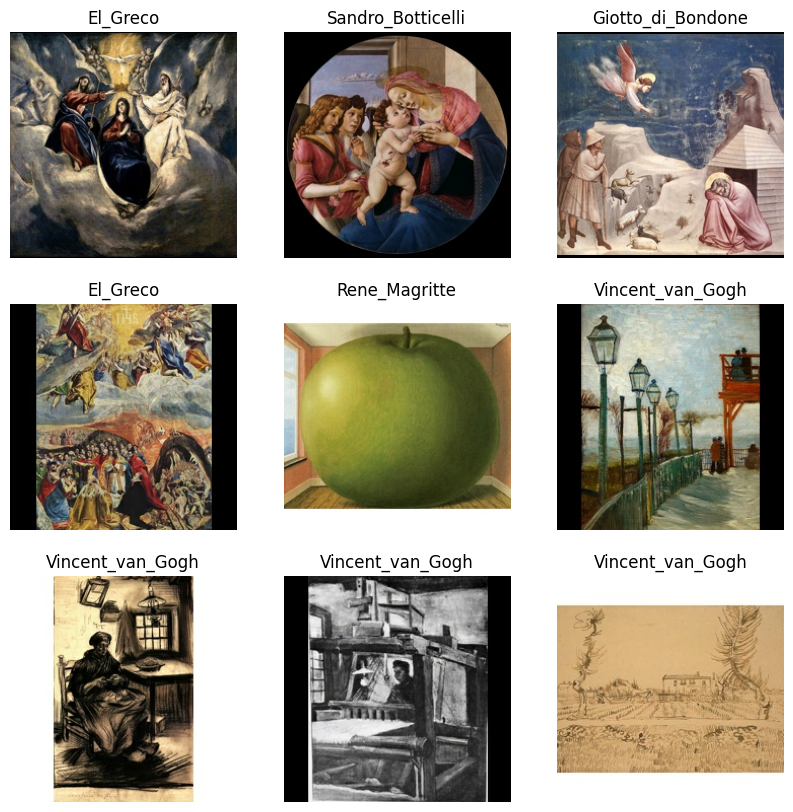

In [4]:
class_names = train.class_names
print(len(class_names))

plt.figure(figsize=(10, 10))
for images, labels in train.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

# CNN Implementation

In [27]:
def model_builder(hp):
  # Define the model's input
  inputs = keras.Input(shape=(224, 224, 3))

  # Apply data augmentation layers sequentially to the tensor
  x = keras.layers.RandomFlip("horizontal_and_vertical")(inputs)
  x = keras.layers.RandomRotation(0.2)(x)

  # Load the base model and set it to non-trainable
  base_model = tf.keras.applications.EfficientNetB0(
      include_top=False,
      input_shape=(224, 224, 3),
      pooling='avg',
  )
  base_model.trainable = False

  # Pass the augmented input tensor to the base_model
  x = base_model(x)

  # Add custom top layers
  x = tf.keras.layers.Dropout(0.35)(x)
  outputs = tf.keras.layers.Dense(27, activation='softmax')(x)

  # Create the final model
  model = tf.keras.Model(inputs=inputs, outputs=outputs)

  hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
      loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
      metrics=['accuracy']
  )

  return model

In [28]:
tuner = kt.Hyperband(
    model_builder,
    objective='accuracy',
    max_epochs=10,
    factor=3,
    directory='my_dir',
    project_name='best_params'
)

stop_early = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=5
)

tuner.search(x=train, epochs=50, callbacks=[stop_early])


Trial 3 Complete [00h 05m 59s]
accuracy: 0.5008658170700073

Best accuracy So Far: 0.5008658170700073
Total elapsed time: 01h 38m 58s


In [34]:
best_params = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_params)
model = tuner.hypermodel.build(best_params)
history = model.fit(train, epochs=5)

Epoch 1/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.2002 - loss: 2.9059
Epoch 2/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.4879 - loss: 1.8620
Epoch 3/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.5734 - loss: 1.4995
Epoch 4/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.6174 - loss: 1.3129
Epoch 5/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.6566 - loss: 1.2031


In [35]:
model.evaluate(test)

25/25 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.6152 - loss: 1.3918


[1.3744840621948242, 0.6124837398529053]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Model prediction (probabilities): [[8.0600316e-03 1.1867199e-03 3.2841941e-05 9.7982062e-04 1.6766021e-02
  1.0131859e-02 1.6855629e-03 6.9971126e-01 1.6576370e-03 7.7859993e-05
  3.6683090e-03 1.2886299e-04 5.5199312e-03 1.1779717e-02 5.3328732e-03
  1.2185661e-03 7.8548968e-04 1.5215816e-03 3.0106246e-03 5.9230387e-04
  9.2085628e-03 1.1867811e-02 6.6753668e-03 1.9569017e-03 3.8850703e-03
  1.7173680e-04 1.9238666e-01]]


Predicted class: Francisco_Goya
True class: Francisco_Goya


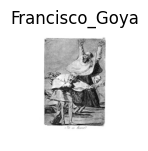

In [47]:
for images, labels in test.take(1):
  ax = plt.subplot(3, 3, 1)
  plt.imshow(images[2].numpy().astype("uint8"))
  plt.title(class_names[labels[2]])
  plt.axis("off")

  # Add a batch dimension to the single image before prediction
  single_image = np.expand_dims(images[2].numpy(), axis=0)
  predictions = model.predict(single_image)
  print("Model prediction (probabilities):", predictions)
  predicted_class = np.argmax(predictions)
  print(f"\n\nPredicted class: {class_names[predicted_class]}")
  print(f"True class: {class_names[labels[2]]}")
  break

In [49]:
model.save('model.keras')